# Credit Scoring — Give Me Some Credit & Home Credit

---
## Cấu trúc notebook

| Phần | Nội dung |
|------|----------|
| 0 | Setup & cài thư viện
| 1 | Shared utilities (evaluate, plot, TabNet classes)
| A | Give Me Some Credit — Load → EDA → FE → Preprocess → Train
| B | Report 
| C | Save

# 0. Setup & Reproducibility

In [1]:
import os, sys, time, warnings, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
SAVE_DIR   = f'{OUTPUT_DIR}/saved_models'


print("python  :", sys.version)
print("platform:", platform.platform())
print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)


python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
platform: Linux-6.12.90+-x86_64-with-glibc2.35
numpy   : 2.4.6
pandas  : 2.3.3


In [2]:
import torch, gc
torch.cuda.empty_cache()
gc.collect()
torch.cuda.synchronize()

In [3]:
import torch
import optuna
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report,
)
from category_encoders import WOEEncoder
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder, QuantileTransformer

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')


Imports OK


In [4]:
!pip install pytorch_tabnet 
from pytorch_tabnet.tab_model import TabNetClassifier
print('pytorch_tabnet OK')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.8 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23

---
# 1. Shared Utilities
> Tất cả hàm dùng chung cho cả 2 dataset.  
> Chạy một lần, dùng xuyên suốt notebook.


## 1.1 Evaluate metrics

In [5]:
def evaluate(model, X, y_true, label='', threshold=None):
    y_prob = model.predict_proba(X)[:, 1]
    y_true = np.array(y_true)
    auc    = roc_auc_score(y_true, y_prob)
    ap     = average_precision_score(y_true, y_prob)
    gini   = 2 * auc - 1
    fpr, tpr, thr_roc = roc_curve(y_true, y_prob)
    ks_scores   = tpr - fpr
    ks          = ks_scores.max()
    
    if threshold is not None:
        best_thresh = threshold
    else:
        best_thresh = float(thr_roc[ks_scores.argmax()])
    
    y_pred      = (y_prob >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall_bad     = tp / (tp + fn + 1e-8)
    recall_good    = tn / (tn + fp + 1e-8)
    precision_bad  = tp / (tp + fp + 1e-8)
    f1_bad         = 2 * precision_bad * recall_bad / (precision_bad + recall_bad + 1e-8)
    if label:
        print(f"  [{label}] AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}  F1(bad)={f1_bad:.4f}")
    return dict(auc=auc, gini=gini, ks=ks, ap=ap, threshold=best_thresh,
                recall_bad=recall_bad, recall_good=recall_good,
                precision_bad=precision_bad, f1_bad=f1_bad,
                tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))

## 1.2 Summarize & 1.3 Plot baseline results

In [6]:
def summarize_results(results):
    rows = []
    for name, r in results.items():
        tr, te = r['train'], r['test']
        rows.append({
            'Model'          : name,
            'Train AUC'      : round(tr['auc'],           4),
            'Test AUC'       : round(te['auc'],           4),
            'Test Gini'      : round(te['gini'],          4),
            'Test KS'        : round(te['ks'],            4),
            'Precision (Bad)': round(te['precision_bad'], 4),
            'Recall (Bad)'   : round(te['recall_bad'],    4),
            'Recall (Good)'  : round(te['recall_good'],   4),
            'F1 (Bad)'       : round(te['f1_bad'],        4),
            'TP': int(te['tp']), 'FP': int(te['fp']),
            'TN': int(te['tn']), 'FN': int(te['fn']),
            'Threshold'      : round(te['threshold'],     4),
            'Train Time (s)' : r['train_time_s'],
        })
    return (pd.DataFrame(rows)
              .sort_values('Test AUC', ascending=False)
              .reset_index(drop=True))

def append_to_summary(df_summary, model_name, train_m, test_m, train_time=None):
    new_row = pd.DataFrame([{
        'Model'          : model_name,
        'Train AUC'      : round(train_m['auc'],           4),
        'Test AUC'       : round(test_m['auc'],            4),
        'Test Gini'      : round(test_m['gini'],           4),
        'Test KS'        : round(test_m['ks'],             4),
        'Precision (Bad)': round(test_m['precision_bad'],  4),
        'Recall (Bad)'   : round(test_m['recall_bad'],     4),
        'Recall (Good)'  : round(test_m['recall_good'],    4),
        'F1 (Bad)'       : round(test_m['f1_bad'],         4),
        'TP': int(test_m['tp']), 'FP': int(test_m['fp']),
        'TN': int(test_m['tn']), 'FN': int(test_m['fn']),
        'Threshold'      : round(test_m['threshold'],      4),
        'Train Time (s)' : train_time,
    }])
    df_summary = df_summary[df_summary['Model'] != model_name].reset_index(drop=True)
    return (pd.concat([df_summary, new_row], ignore_index=True)
              .sort_values('Test AUC', ascending=False)
              .reset_index(drop=True))


def plot_baseline(df_summary, title_suffix='', output_dir=OUTPUT_DIR):
    tag   = title_suffix.replace(' ', '_').lower()
    names = df_summary['Model']
    x     = np.arange(len(names))
    w     = 0.18

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (m, c) in enumerate(zip(
        ['Test AUC','Test Gini','Test KS','F1 (Bad)','Recall (Bad)'],
        ['#2E86C1','#1ABC9C','#E67E22','#8E44AD','#E74C3C']
    )):
        ax.bar(x + i*w, df_summary[m], w, label=m, color=c, alpha=0.85)
    ax.set_xticks(x + w*2)
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
    ax.set_title(f'Baseline Comparison {title_suffix}', fontsize=13)
    ax.legend(loc='lower right', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/baseline_metrics_{tag}.png', dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x-w/2, df_summary['Train AUC'], w, label='Train AUC', color='#2E86C1', alpha=0.85)
    ax.bar(x+w/2, df_summary['Test AUC'],  w, label='Test AUC',  color='#E74C3C', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
    ax.set_title(f'Train vs Test AUC — Overfit Check {title_suffix}', fontsize=13)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/overfit_check_{tag}.png', dpi=150)
    plt.show()


def plot_final(results_baseline, extra_models, X_test_bl, y_test,
               df_summary, title_suffix='', output_dir=OUTPUT_DIR):
    tag  = title_suffix.lower().replace(' ', '_')
    y_te = y_test.values if hasattr(y_test, 'values') else y_test

    plot_models = [(n, results_baseline[n]['model'], X_test_bl, '#B4B2A9')
                   for n in ['LightGBM', 'CatBoost'] if n in results_baseline]
    plot_models += extra_models

    # ROC
    fig, ax = plt.subplots(figsize=(8, 7))
    for name, model, X_eval, color in plot_models:
        y_prob       = model.predict_proba(X_eval)[:, 1]
        fpr, tpr, _  = roc_curve(y_te, y_prob)
        auc          = roc_auc_score(y_te, y_prob)
        lw = 2.5 if 'TabNet' in name else 1.5
        ls = '-'  if 'TabNet' in name else '--'
        ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
                label=f'{name} (AUC={auc:.4f})')
    ax.plot([0,1],[0,1], 'k--', alpha=0.3)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Curve — {title_suffix}')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/roc_{tag}.png', dpi=150)
    plt.show()

    # PR
    fig, ax = plt.subplots(figsize=(8, 7))
    for name, model, X_eval, color in plot_models:
        y_prob       = model.predict_proba(X_eval)[:, 1]
        prec, rec, _ = precision_recall_curve(y_te, y_prob)
        ap           = average_precision_score(y_te, y_prob)
        lw = 2.5 if 'TabNet' in name else 1.5
        ls = '-'  if 'TabNet' in name else '--'
        ax.plot(rec, prec, color=color, linewidth=lw, linestyle=ls,
                label=f'{name} (AP={ap:.4f})')
    ax.axhline(y_te.mean(), color='gray', linestyle=':', alpha=0.6, label='Random')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall — {title_suffix}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/pr_{tag}.png', dpi=150)
    plt.show()

    # Final bar
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    bar_colors = [
        '#534AB7' if 'Stacking' in m
        else '#1D9E75' if 'Improved' in m or 'MHA' in m
        else '#9FE1CB' if 'single' in m or 'no-FE' in m
        else '#B4B2A9'
        for m in df_summary['Model']
    ]
    for ax, metric in zip(axes, ['Test AUC', 'Test KS', 'F1 (Bad)']):
        bars = ax.barh(df_summary['Model'], df_summary[metric],
                       color=bar_colors, alpha=0.88, height=0.6)
        ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
        ax.set_xlim(df_summary[metric].min()-0.01, df_summary[metric].max()+0.02)
        ax.set_title(metric)
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()
    plt.suptitle(f'Final Model Comparison — {title_suffix}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/final_comparison_{tag}.png', dpi=150)
    plt.show()

## 1.4 Preprocessing

In [7]:
def impute_median_group(X_train, X_test, group_col, target_col):
    medians    = X_train.groupby(group_col, observed=True)[target_col].median()
    global_med = X_train[target_col].median()
    for df in [X_train, X_test]:
        mask = df[target_col].isna()
        df.loc[mask, target_col] = df.loc[mask, group_col].map(medians).fillna(global_med)
    return X_train, X_test


def impute_all_numeric(X_train, X_test, skip_cols=None):
    skip_cols = skip_cols or []
    num_cols  = X_train.select_dtypes(include='number').columns
    for col in [c for c in num_cols if c not in skip_cols]:
        med = X_train[col].median()
        X_train[col] = X_train[col].fillna(med)
        X_test[col]  = X_test[col].fillna(med)
    return X_train, X_test


def cap_iqr(X_train, X_test, skip_cols=None, p_low=5, p_high=95):
    skip_cols = skip_cols or []
    num_cols  = X_train.select_dtypes(include='number').columns
    for col in [c for c in num_cols if c not in skip_cols]:
        data = X_train[col].dropna()
        Q1, Q3 = np.percentile(data, 25), np.percentile(data, 75)
        IQR    = Q3 - Q1
        if ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).any():
            lo = np.percentile(data, p_low)
            hi = np.percentile(data, p_high)
            X_train[col] = X_train[col].clip(lo, hi)
            X_test[col]  = X_test[col].clip(lo, hi)
    return X_train, X_test

In [8]:
def encode_categoricals(X_train, X_test):
    """LabelEncoder cho tất cả object/category cols — dùng cho TabNet pipeline."""
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
        le.fit(combined)
        X_train[col] = le.transform(X_train[col].astype(str))
        X_test[col]  = le.transform(X_test[col].astype(str))
        encoders[col] = le
    return X_train, X_test, encoders


def apply_woe_scale(X_train, X_test, y_train):
    """WOE encode cat cols + StandardScaler num cols — dùng cho baseline."""
    X_train, X_test = X_train.copy(), X_test.copy()
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X_train.select_dtypes(include='number').columns.tolist()
    woe_enc  = None
    if cat_cols:
        woe_enc = WOEEncoder(cols=cat_cols, handle_unknown='value', handle_missing='value')
        woe_enc.fit(X_train[cat_cols], y_train)
        X_train[cat_cols] = woe_enc.transform(X_train[cat_cols])
        X_test[cat_cols]  = woe_enc.transform(X_test[cat_cols])
    scaler = StandardScaler()
    if num_cols:
        scaler.fit(X_train[num_cols])
        X_train[num_cols] = scaler.transform(X_train[num_cols])
        X_test[num_cols]  = scaler.transform(X_test[num_cols])
    return X_train, X_test, woe_enc, scaler

In [9]:
def preprocess_for_tabnet(X_train, X_test, skip_impute_cols=None):
    X_train, X_test = X_train.copy(), X_test.copy()
    
    # 1. Encode categoricals
    X_train, X_test, encoders = encode_categoricals(X_train, X_test)
    
    # 2. Impute TRƯỚC khi transform
    X_train, X_test = impute_all_numeric(X_train, X_test, skip_cols=skip_impute_cols)
    
    # 3. QuantileTransform
    num_cols = X_train.select_dtypes(include='number').columns.tolist()
    qt = QuantileTransformer(output_distribution='normal', 
                              n_quantiles=min(1000, len(X_train)),  # tránh n_quantiles > n_samples
                              random_state=42)
    qt.fit(X_train[num_cols])
    X_train[num_cols] = qt.transform(X_train[num_cols])
    X_test[num_cols]  = qt.transform(X_test[num_cols])
    
    # 4. Clip outlier sau transform (QT không hoàn toàn loại outlier với unseen data)
    X_train[num_cols] = X_train[num_cols].clip(-5, 5)
    X_test[num_cols]  = X_test[num_cols].clip(-5, 5)
    
    print(f'  TabNet input: train={X_train.shape} | test={X_test.shape}')
    return X_train, X_test, qt

## 1.5 Baseline models 

In [10]:
def build_baseline_models(bad_weight, n_samples=10000):
    min_leaf = max(20, n_samples // 2000)
    return {     
        'Logistic Regression': LogisticRegression(
        class_weight={0:1, 1:bad_weight},
        random_state=42),                    
    
        'Decision Tree': DecisionTreeClassifier(
        class_weight={0:1, 1:bad_weight},
        max_depth=6,   
        random_state=42),                    
    
        'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=min_leaf,
        max_features='sqrt',
        class_weight={0: 1, 1: bad_weight},
        random_state=RANDOM_SEED,
        n_jobs=-1),                                   
        
        'XGBoost': XGBClassifier(
            scale_pos_weight=bad_weight,
            eval_metric='auc',
            random_state=42,
            verbosity=0),                        
        
        'LightGBM': LGBMClassifier(
            scale_pos_weight=bad_weight,
            random_state=42,
            verbose=-1),
        
        'CatBoost': CatBoostClassifier(
            scale_pos_weight=bad_weight,
            random_seed=42,
            verbose=0),
       
    }



def train_baseline_models(models, X_tr, X_te, y_tr, y_te):
    results = {}
    for name, model in models.items():
        print(f'  Training {name} ...', end=' ')
        t0 = time.time()
        model.fit(X_tr, y_tr)
        elapsed = time.time() - t0
        print(f'({elapsed:.1f}s)')
        y_te_np = y_te.values if hasattr(y_te, 'values') else np.array(y_te)
        y_prob  = model.predict_proba(X_te)[:, 1]
        te_m    = evaluate(model, X_te, y_te, label='test')
        results[name] = {
            'model'       : model,
            'train'       : evaluate(model, X_tr, y_tr, label='train'),
            'test'        : te_m,
            'train_time_s': round(elapsed, 2),
            'y_true'      : y_te_np,
            'y_prob'      : y_prob,
            'auc'         : te_m['auc'],
        }
    return results

## 1.6 TabNet architecture (ImprovedTabNet)

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha, self.gamma, self.pos_weight = alpha, gamma, pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none')
        pt  = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


class MultiHeadAttention(nn.Module):
    def __init__(self, n_features, d_model=64, n_heads=8, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model, self.n_heads = d_model, n_heads
        self.d_k  = d_model // n_heads
        self.W_Q  = nn.Linear(1, d_model)
        self.W_K  = nn.Linear(1, d_model)
        self.W_V  = nn.Linear(1, d_model)
        self.W_O  = nn.Linear(d_model, 1)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(n_features)

    def forward(self, x):
        B, F_ = x.shape
        t     = x.unsqueeze(-1)
        Q, K, V = self.W_Q(t), self.W_K(t), self.W_V(t)
        def sh(z): return z.view(B, F_, self.n_heads, self.d_k).transpose(1, 2)
        Q, K, V = sh(Q), sh(K), sh(V)
        A   = self.drop(torch.softmax(Q @ K.transpose(-2,-1) / self.d_k**0.5, dim=-1))
        out = (A @ V).transpose(1,2).contiguous().view(B, F_, self.d_model)
        return self.norm(self.W_O(out).squeeze(-1) + x)

In [12]:
class ImprovedTabNetClassifier(nn.Module):
    def __init__(self, n_features, n_d=64, n_steps=5,
                 n_heads=8, d_model=64, dropout=0.1, gamma=1.5,
                 use_mha=True):                          # <-- THÊM
        super().__init__()
        self.n_features, self.n_steps, self.n_d, self.gamma = n_features, n_steps, n_d, gamma
        self.use_mha = use_mha                            # <-- THÊM

        if self.use_mha:
            self.mha_local  = MultiHeadAttention(n_features, d_model, n_heads,   dropout)
            self.mha_global = MultiHeadAttention(n_features, d_model*2, n_heads*2, dropout)
            shared_in_dim = n_features * 3
        else:
            self.mha_local  = None
            self.mha_global = None
            shared_in_dim = n_features                    # <-- THÊM: bỏ MHA thì input nhỏ lại

        self.shared_fc = nn.Sequential(
            nn.Linear(shared_in_dim, n_d*2), nn.BatchNorm1d(n_d*2), nn.GLU(dim=-1))

        self.step_fc = nn.ModuleList([
            nn.Sequential(nn.Linear(n_d, n_d*2), nn.BatchNorm1d(n_d*2), nn.GLU(dim=-1))
            for _ in range(n_steps)])

        self.attn_fc = nn.ModuleList([
            nn.Sequential(nn.Linear(n_d, n_features), nn.Softmax(dim=-1))
            for _ in range(n_steps)])

        self.proj_fc = nn.ModuleList([
            nn.Linear(n_features, n_d, bias=False)
            for _ in range(n_steps)])

        self.bn_in = nn.BatchNorm1d(n_features)
        self.drop  = nn.Dropout(dropout)
        self.head  = nn.Linear(n_d, 1)

    def _encode(self, x):
        x = self.bn_in(x)

        if self.use_mha:                                  # <-- THÊM
            h_input = torch.cat([x, self.mha_local(x), self.mha_global(x)], dim=-1)
        else:
            h_input = x

        h = self.shared_fc(h_input)
        prior = torch.ones(x.size(0), self.n_features, device=x.device)
        agg   = torch.zeros(x.size(0), self.n_d,       device=x.device)
        ent   = torch.zeros(1,                          device=x.device)

        for i in range(self.n_steps):
            mask  = self.attn_fc[i](h) * prior
            mask  = mask / (mask.sum(-1, keepdim=True) + 1e-8)
            prior = prior * (self.gamma - mask)
            ent   = ent + (-mask * torch.log(mask + 1e-15)).sum(-1).mean()

            proj  = torch.relu(self.proj_fc[i](mask * x))
            step_out = torch.relu(self.step_fc[i](h) + proj * 0.5)
            agg  += step_out
            h = h + self.drop(step_out)

        return agg / self.n_steps, ent / self.n_steps

    def get_embedding(self, x):
        emb, _ = self._encode(x)
        return emb

    def forward(self, x):
        emb, ent = self._encode(x)
        return self.head(emb).squeeze(-1), ent

In [13]:
class ModelWrapper:
    def __init__(self, model, device):
        self.model, self.device = model, device

    def predict_proba(self, X):
        if hasattr(X, 'values'): X = X.values
        self.model.eval()
        out = []
        with torch.no_grad():
            for (xb,) in DataLoader(
                TensorDataset(torch.tensor(X.astype(np.float32))), batch_size=2048):
                lg, _ = self.model(xb.to(self.device))
                out.append(torch.sigmoid(lg).cpu().numpy())
        p = np.concatenate(out)
        return np.column_stack([1-p, p])


class MetaWrapper:
    def __init__(self, models, lgbm):
        self.models, self.lgbm = models, lgbm

    def predict_proba(self, X):
        if hasattr(X, 'values'): X = X.values
        X = X.astype(np.float32)
        actual_n_d = self.models[0][0].head.in_features
        if X.shape[1] == actual_n_d + 1:
            return self.lgbm.predict_proba(X)
        avg_p = np.zeros(len(X))
        avg_e = np.zeros((len(X), actual_n_d))
        for m, d in self.models:
            avg_p += infer_batch(m, X, d, mode='proba')     / len(self.models)
            avg_e += infer_batch(m, X, d, mode='embedding') / len(self.models)
        return self.lgbm.predict_proba(np.hstack([avg_e, avg_p.reshape(-1,1)]))

In [14]:
def infer_batch(model, X_np, device, batch_size=2048, mode='proba'):
    if hasattr(X_np, 'values'): X_np = X_np.values
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[s:s+batch_size].astype(np.float32)).to(device)
            if mode == 'proba':
                lg, _ = model(xb)
                out.append(torch.sigmoid(lg).cpu().numpy())
            else:
                out.append(model.get_embedding(xb).cpu().numpy())
            torch.cuda.empty_cache()
    return np.concatenate(out) if mode == 'proba' else np.vstack(out)

print('✓ Architecture classes ready')

✓ Architecture classes ready


## 1.7 Train Improved TabNet 

In [15]:
def train_improved_tabnet(
    X_train, X_test, y_train, y_test, bad_weight,
    n_d=64, n_steps=5, n_heads=8, d_model=64,
    dropout=0.1, gamma=1.5, lambda_sparse=1e-4, focal_gamma=2.0,
    lr=1e-3, weight_decay=1e-5, batch_size=1024,
    max_epochs=150, patience=20, verbose_every=10,
    warmup_epochs=0, seed=42,
    loss_type='focal',   # 'focal' hoặc 'bce'
    use_mha=True,        # <-- THÊM
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)   # sửa luôn dùng seed thay vì hard-code 42
    np.random.seed(seed)                                              # sửa luôn dùng seed thay vì hard-code 42

    def to_np(z, dt): return z.values.astype(dt) if hasattr(z,'values') else np.array(z, dtype=dt)
    X_tr = torch.tensor(to_np(X_train, np.float32))
    X_te = torch.tensor(to_np(X_test,  np.float32))
    y_tr = torch.tensor(to_np(y_train, np.float32))
    y_te = torch.tensor(to_np(y_test,  np.float32))

    if loss_type == 'focal':
        crit = FocalLoss(0.75, focal_gamma, torch.tensor([bad_weight]).to(device))
    elif loss_type == 'bce':
        crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([bad_weight]).to(device))
    else:
        raise ValueError("loss_type phải là 'focal' hoặc 'bce'")

    train_dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size,
                          shuffle=True, pin_memory=True)
    test_dl  = DataLoader(TensorDataset(X_te, y_te), batch_size=2048,
                          shuffle=False, pin_memory=True)

    model = ImprovedTabNetClassifier(
        X_tr.shape[1], n_d, n_steps, n_heads, d_model, dropout, gamma,
        use_mha=use_mha).to(device)                       # <-- THÊM use_mha

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if warmup_epochs > 0:
        warmup = LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
        cosine = CosineAnnealingLR(opt, T_max=max_epochs - warmup_epochs, eta_min=1e-6)
        sch    = SequentialLR(opt, schedulers=[warmup, cosine], milestones=[warmup_epochs])
    else:
        sch    = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=1e-6)

    best_auc, best_state, no_imp, history = 0.0, None, 0, []
    t0 = time.time()
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            lg, ent = model(xb)
            (crit(lg, yb) + lambda_sparse * ent).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()
        model.eval(); ps, ls = [], []
        with torch.no_grad():
            for xb, yb in test_dl:
                lg, _ = model(xb.to(device))
                ps.append(torch.sigmoid(lg).cpu()); ls.append(yb)
        auc = roc_auc_score(torch.cat(ls).numpy(), torch.cat(ps).numpy())
        history.append(auc)
        if (epoch+1) % verbose_every == 0 or epoch == 0:
            print(f'    Epoch {epoch+1:3d} | test_auc={auc:.5f} | {time.time()-t0:.0f}s')
        if auc > best_auc + 1e-5:
            best_auc   = auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp     = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f'    Early stop @ epoch {epoch+1} | best={best_auc:.5f}')
                break

    model.load_state_dict(best_state)
    model.to(device)
    wrapper = ModelWrapper(model, device)
    tr_m = evaluate(wrapper, to_np(X_train, np.float32), to_np(y_train, np.int64), label='train')
    te_m = evaluate(wrapper, to_np(X_test,  np.float32), to_np(y_test,  np.int64), label='test')
    print(f'  Done {time.time()-t0:.1f}s | Train AUC={tr_m["auc"]:.4f} | '
          f'Test AUC={te_m["auc"]:.4f} | Gap={tr_m["auc"]-te_m["auc"]:.4f}')
    return wrapper, tr_m, te_m, history, model, device

print('✓ Architecture classes ready (with use_mha toggle)')

✓ Architecture classes ready (with use_mha toggle)


## 1.8 SHAP 

In [17]:
def run_shap_analysis(model_raw, X_train_np, X_test_np, y_test_np,
                       feat_names, tag='', output_dir=OUTPUT_DIR,
                       n_background=500, n_explain=500):
    """
    Dùng GradientExplainer thay KernelExplainer — nhanh hơn 100x trên GPU.
    model_raw: raw PyTorch module (không phải wrapper).
    """
    device = next(model_raw.parameters()).device
    model_raw.eval()

    # Wrapper để GradientExplainer hiểu (output scalar probability)
    class _ShapModel(nn.Module):
        def __init__(self, base): super().__init__(); self.base = base
        def forward(self, x):
            lg, _ = self.base(x)
            return torch.sigmoid(lg).unsqueeze(1)

    shap_model = _ShapModel(model_raw)

    # Background: sample ngẫu nhiên từ train
    np.random.seed(42)
    bg_idx  = np.random.choice(len(X_train_np), size=n_background, replace=False)
    X_bg    = torch.tensor(X_train_np[bg_idx]).to(device)

    # Explain samples từ test
    ex_idx  = np.random.choice(len(X_test_np), size=n_explain, replace=False)
    X_ex    = torch.tensor(X_test_np[ex_idx]).to(device)

    explainer  = shap.GradientExplainer(shap_model, X_bg)
    shap_vals  = explainer.shap_values(X_ex)

    # GradientExplainer returns list for multi-output; take [0] and squeeze
    if isinstance(shap_vals, list):
        sv = shap_vals[0]
    else:
        sv = shap_vals
    if sv.ndim == 3:
        sv = sv[:, :, 0]  # (N, F, 1) → (N, F)

    sv_np = sv if isinstance(sv, np.ndarray) else sv.cpu().numpy()
    X_ex_np = X_ex.cpu().numpy()

    # ── Bar plot (mean |SHAP|) ────────────────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv_np, X_ex_np, feature_names=feat_names,
                      plot_type='bar', max_display=15, show=False)
    plt.title(f'SHAP Feature Importance — Improved TabNet ({tag})', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/shap_bar_{tag.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Beeswarm ──────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv_np, X_ex_np, feature_names=feat_names,
                      max_display=15, show=False)
    plt.title(f'SHAP Beeswarm — Improved TabNet ({tag})', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/shap_beeswarm_{tag.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Local waterfall: 1 bad + 1 good ──────────────────────────────────────
    y_ex = y_test_np[ex_idx]
    bad_idx  = np.where(y_ex == 1)[0]
    good_idx = np.where(y_ex == 0)[0]

    if len(bad_idx) > 0 and len(good_idx) > 0:
        try:
            base_val = float(np.mean(torch.sigmoid(
                shap_model(X_bg)).detach().cpu().numpy()))
        except:
            base_val = 0.5
        for si, label in [(bad_idx[0], 'bad_customer'), (good_idx[0], 'good_customer')]:
            exp = shap.Explanation(
                values        = sv_np[si],
                base_values   = base_val,
                data          = X_ex_np[si],
                feature_names = feat_names
            )
            plt.figure(figsize=(10, 6))
            shap.waterfall_plot(exp, max_display=12, show=False)
            plt.title(f'SHAP Waterfall — {label.replace("_"," ").title()} ({tag})', fontsize=12)
            plt.tight_layout()
            plt.savefig(f'{output_dir}/shap_waterfall_{tag.lower().replace(" ","_")}_{label}.png',
                        dpi=150, bbox_inches='tight')
            plt.show()

    # ── Mean |SHAP| summary ───────────────────────────────────────────────────
    mean_shap = pd.Series(np.abs(sv_np).mean(axis=0), index=feat_names).sort_values(ascending=False)
    print(f'\nTop 10 SHAP features ({tag}):')
    print(mean_shap.head(10).to_string())
    mean_shap.to_csv(f'{output_dir}/shap_importance_{tag.lower().replace(" ","_")}.csv')
    return sv_np, mean_shap

## 1.9 Risk tiering

In [18]:
def run_risk_tiering(wrapper, X_np, y_np, tag='', output_dir=OUTPUT_DIR,
                     bins=[0, 0.1, 0.3, 0.5, 1.0],
                     labels=['Low (0–10%)', 'Medium (10–30%)', 'High (30–50%)', 'Very High (>50%)']):
    prob = wrapper.predict_proba(X_np)[:, 1]
    df   = pd.DataFrame({'prob': prob, 'actual': y_np})
    bins   = [0, 0.1, 0.3, 0.5, 1.0]
    labels = ['Low (0–10%)', 'Medium (10–30%)', 'High (30–50%)', 'Very High (>50%)']
    df['tier'] = pd.cut(df['prob'], bins=bins, labels=labels, include_lowest=True)
    stats = df.groupby('tier', observed=True).agg(
        Count   = ('actual', 'count'),
        Bad_Rate= ('actual', 'mean'),
        Avg_Prob= ('prob',   'mean')
    ).reset_index()
    stats['Bad_Rate_pct'] = (stats['Bad_Rate'] * 100).round(2)
    print(f'\n── Risk Tiering ({tag}) ──')
    print(stats.to_string(index=False))
    stats.to_csv(f'{output_dir}/risk_tiering_{tag.lower().replace(" ","_")}.csv', index=False)

    colors = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].bar(stats['tier'], stats['Bad_Rate_pct'], color=colors, alpha=0.85)
    axes[0].set_title(f'Bad Rate by Risk Tier — {tag}')
    axes[0].set_ylabel('Bad Rate (%)')
    axes[0].tick_params(axis='x', rotation=15)
    for i, v in enumerate(stats['Bad_Rate_pct']):
        axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

    data_by_tier = [df[df['tier'] == t]['prob'].values for t in labels]
    valid = [(i, d) for i, d in enumerate(data_by_tier) if len(d) > 1]
    
    if valid:
        positions, data_valid = zip(*valid)
        bp = axes[1].violinplot(list(data_valid), positions=list(positions), showmedians=True)
        for patch, c in zip(bp['bodies'], [colors[i] for i in positions]):
            patch.set_facecolor(c); patch.set_alpha(0.7)
    
    axes[1].set_xticks(range(4))
    axes[1].set_xticklabels([l.split(' ')[0] for l in labels])
    
    for patch, c in zip(bp['bodies'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    axes[1].set_xticks(range(4))
    axes[1].set_xticklabels([l.split(' ')[0] for l in labels])
    axes[1].set_title(f'Probability Distribution by Tier — {tag}')
    axes[1].set_ylabel('Predicted Probability')

    plt.suptitle(f'Risk Tiering — Improved TabNet ({tag})', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/risk_tiering_{tag.lower().replace(" ","_")}.png', dpi=150)
    plt.show()
    return stats

## 10. Optuna

In [40]:
import optuna
from sklearn.metrics import roc_auc_score

def objective(trial):

    params = {
        "n_d": trial.suggest_categorical("n_d", [32, 64, 96, 128]),
        "n_steps": trial.suggest_int("n_steps", 3, 8),

        "n_heads": trial.suggest_categorical("n_heads", [2, 4, 8]),
        "d_model": trial.suggest_categorical("d_model", [32, 64, 96, 128]),

        "gamma": trial.suggest_float("gamma", 1.0, 2.0),
        "lambda_sparse": trial.suggest_float(
            "lambda_sparse", 1e-6, 1e-3, log=True
        ),

        "focal_gamma": trial.suggest_float("focal_gamma", 1.0, 4.0),

        "dropout": trial.suggest_float("dropout", 0.0, 0.4),

        "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),

        "wd": trial.suggest_float(
            "wd", 1e-7, 1e-3, log=True
        ),

        "batch_size": trial.suggest_categorical(
            "batch_size", [256, 512, 1024]
        )
    }

    wrapper, tr_m, te_m, hist, raw_model, dev = train_improved_tabnet(
        X_gm_train_tn,
        X_gm_test_tn,
        y_gm_train,
        y_gm_test,
        bad_w_gm,

        n_d=params["n_d"],
        n_steps=params["n_steps"],

        n_heads=params["n_heads"],
        d_model=params["d_model"],

        gamma=params["gamma"],
        lambda_sparse=params["lambda_sparse"],

        focal_gamma=params["focal_gamma"],

        dropout=params["dropout"],

        lr=params["lr"],
        weight_decay=params["wd"],
        batch_size=params["batch_size"],

        loss_type="focal",
        use_mha=True,

        max_epochs=80,
        patience=15,
        warmup_epochs=10,
        seed=42
    )

    return te_m["auc"]

---
# PHẦN A — Give Me Some Credit Dataset
> Pipeline hoàn chỉnh: Load → EDA → Feature Engineering → Preprocessing → Baseline → TabNet


## A1. Load data

In [19]:
PATH_GIVEME = '/kaggle/input/datasets/phmththuvn/gmsc-vv-dataset/cs-training.csv'
TARGET_GM   = 'SeriousDlqin2yrs'
GMSC_RAW_COLS = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
]

df_gm = pd.read_csv(PATH_GIVEME).reset_index(drop=True)
print(f'Shape: {df_gm.shape}')
print(df_gm[TARGET_GM].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Shape: (150000, 12)
SeriousDlqin2yrs
0    93.32%
1     6.68%
Name: proportion, dtype: object


## A2. EDA

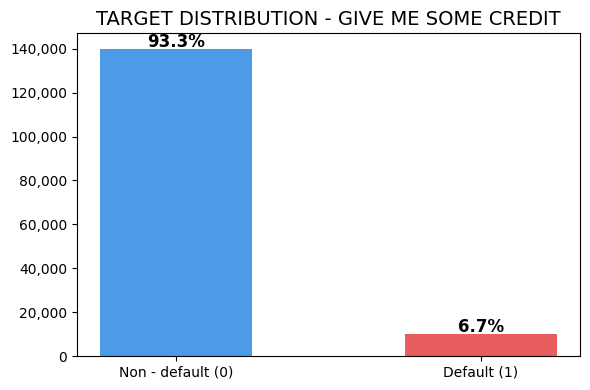

In [20]:

target_counts = df_gm['SeriousDlqin2yrs'].value_counts()
target_pct = df_gm['SeriousDlqin2yrs'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Non - default (0)', 'Default (1)'],
    target_counts.values,
    color=['#4C9BE8', '#E85D5D'],
    width=0.5
)

for bar, pct in zip(bars, target_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f'{pct}%',
        ha='center', fontsize=12, fontweight='bold'
    )

ax.set_title('TARGET DISTRIBUTION - GIVE ME SOME CREDIT', fontsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## A3. Split TRƯỚC feature engineering

QUAN TRỌNG: split trước để no-FE pipeline dùng cùng random state¶


In [21]:
X_gm_raw = df_gm[GMSC_RAW_COLS].copy()
y_gm     = df_gm[TARGET_GM].copy()

X_gm_train_raw, X_gm_test_raw, y_gm_train, y_gm_test = train_test_split(
    X_gm_raw, y_gm, test_size=0.2, random_state=RANDOM_SEED, stratify=y_gm)

print(f'Train: {X_gm_train_raw.shape} | Test: {X_gm_test_raw.shape}')
print(f'Bad rate — train: {y_gm_train.mean():.4f} | test: {y_gm_test.mean():.4f}')

n_good_gm = (y_gm_train == 0).sum()
n_bad_gm  = (y_gm_train == 1).sum()
bad_w_gm  = n_good_gm / n_bad_gm
print(f'Class weight (bad): {bad_w_gm:.2f}')

Train: (120000, 10) | Test: (30000, 10)
Bad rate — train: 0.0668 | test: 0.0668
Class weight (bad): 13.96


##  A4. Feature Engineering

In [22]:
df_gm_fe = df_gm[GMSC_RAW_COLS + [TARGET_GM]].copy()

df_gm_fe['TotalPastDue']      = (df_gm_fe['NumberOfTime30-59DaysPastDueNotWorse'] +
                                   df_gm_fe['NumberOfTime60-89DaysPastDueNotWorse'] +
                                   df_gm_fe['NumberOfTimes90DaysLate'])
df_gm_fe['WeightedPastDue']   = (df_gm_fe['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
                                   df_gm_fe['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
                                   df_gm_fe['NumberOfTimes90DaysLate'] * 3)
df_gm_fe['EverLate90']        = (df_gm_fe['NumberOfTimes90DaysLate'] > 0).astype(int)
df_gm_fe['EverLate60']        = (df_gm_fe['NumberOfTime60-89DaysPastDueNotWorse'] > 0).astype(int)
df_gm_fe['EverLate30']        = (df_gm_fe['NumberOfTime30-59DaysPastDueNotWorse'] > 0).astype(int)
df_gm_fe['SeverePastDueRatio']= df_gm_fe['NumberOfTimes90DaysLate'] / (df_gm_fe['TotalPastDue'] + 1)
df_gm_fe['MonthlyDebt']       = df_gm_fe['DebtRatio'] * df_gm_fe['MonthlyIncome']
df_gm_fe['DisposableIncome']  = df_gm_fe['MonthlyIncome'] - df_gm_fe['MonthlyDebt']
df_gm_fe['IncomePerDependent']= df_gm_fe['MonthlyIncome'] / (df_gm_fe['NumberOfDependents'] + 1)
df_gm_fe['TotalLoansAndLines']= (df_gm_fe['NumberOfOpenCreditLinesAndLoans'] +
                                   df_gm_fe['NumberRealEstateLoansOrLines'])
df_gm_fe['RealEstateRatio']   = (df_gm_fe['NumberRealEstateLoansOrLines'] /
                                   (df_gm_fe['TotalLoansAndLines'] + 1))
df_gm_fe['NoCreditLines']     = (df_gm_fe['NumberOfOpenCreditLinesAndLoans'] == 0).astype(int)
df_gm_fe['UtilizationXPastDue'] = (df_gm_fe['RevolvingUtilizationOfUnsecuredLines'] *
                                     df_gm_fe['TotalPastDue'])

print(f'FE: {len(GMSC_RAW_COLS)} raw → {df_gm_fe.shape[1]-1} total features')

# Re-split với cùng index (bảo đảm train/test split nhất quán)
X_gm_fe = df_gm_fe.drop(columns=[TARGET_GM])
X_gm_train_fe = X_gm_fe.loc[X_gm_train_raw.index].copy()
X_gm_test_fe  = X_gm_fe.loc[X_gm_test_raw.index].copy()

FE: 10 raw → 23 total features


## A5. Preprocessing — Baseline (impute → cap → WOE → scale)

In [23]:
X_gm_train_bl = X_gm_train_fe.copy()
X_gm_test_bl  = X_gm_test_fe.copy()

# Impute MonthlyIncome theo nhóm tuổi
X_gm_train_bl['_age_bin'] = pd.cut(X_gm_train_bl['age'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_gm_test_bl['_age_bin']  = pd.cut(X_gm_test_bl['age'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_gm_train_bl, X_gm_test_bl = impute_median_group(
    X_gm_train_bl, X_gm_test_bl, '_age_bin', 'MonthlyIncome')
X_gm_train_bl.drop(columns='_age_bin', inplace=True)
X_gm_test_bl.drop(columns='_age_bin',  inplace=True)
X_gm_train_bl, X_gm_test_bl = impute_all_numeric(X_gm_train_bl, X_gm_test_bl)

# Cap outliers
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']:
    X_gm_train_bl[col] = X_gm_train_bl[col].clip(0, 20)
    X_gm_test_bl[col]  = X_gm_test_bl[col].clip(0, 20)
X_gm_train_bl['RevolvingUtilizationOfUnsecuredLines'] = \
    X_gm_train_bl['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1.5)
X_gm_test_bl['RevolvingUtilizationOfUnsecuredLines']  = \
    X_gm_test_bl['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1.5)
X_gm_train_bl, X_gm_test_bl = cap_iqr(X_gm_train_bl, X_gm_test_bl,
    skip_cols=['NumberOfTime30-59DaysPastDueNotWorse',
               'NumberOfTime60-89DaysPastDueNotWorse',
               'NumberOfTimes90DaysLate',
               'RevolvingUtilizationOfUnsecuredLines'])

# WOE + scale
X_gm_train_bl, X_gm_test_bl, woe_gm, scaler_gm = apply_woe_scale(
    X_gm_train_bl, X_gm_test_bl, y_gm_train)
print(f'Baseline input: train={X_gm_train_bl.shape} | test={X_gm_test_bl.shape}')

Baseline input: train=(120000, 23) | test=(30000, 23)


## A6. Baseline models 

In [28]:
print('='*60)
print('A6. Baseline Models — Give Me Some Credit')
print('='*60)

models_gm    = build_baseline_models(bad_w_gm)
results_gm   = train_baseline_models(models_gm, X_gm_train_bl, X_gm_test_bl,
                                      y_gm_train, y_gm_test)
df_summary_gm = summarize_results(results_gm)
df_summary_gm


A6. Baseline Models — Give Me Some Credit
  Training Logistic Regression ... (1.4s)
  [test] AUC=0.8654  Gini=0.7308  KS=0.5734  F1(bad)=0.3309
  [train] AUC=0.8600  Gini=0.7199  KS=0.5638  F1(bad)=0.3301
  Training Decision Tree ... (0.8s)
  [test] AUC=0.8548  Gini=0.7096  KS=0.5709  F1(bad)=0.3241
  [train] AUC=0.8632  Gini=0.7264  KS=0.5761  F1(bad)=0.3238
  Training Random Forest ... (14.3s)
  [test] AUC=0.8658  Gini=0.7316  KS=0.5824  F1(bad)=0.3341
  [train] AUC=0.8770  Gini=0.7539  KS=0.5992  F1(bad)=0.3403
  Training XGBoost ... (0.7s)
  [test] AUC=0.8500  Gini=0.7000  KS=0.5520  F1(bad)=0.3143
  [train] AUC=0.9442  Gini=0.8883  KS=0.7446  F1(bad)=0.4438
  Training LightGBM ... (0.8s)
  [test] AUC=0.8660  Gini=0.7321  KS=0.5786  F1(bad)=0.3277
  [train] AUC=0.9014  Gini=0.8029  KS=0.6319  F1(bad)=0.3613
  Training CatBoost ... (17.8s)
  [test] AUC=0.8570  Gini=0.7141  KS=0.5612  F1(bad)=0.3243
  [train] AUC=0.9344  Gini=0.8689  KS=0.7239  F1(bad)=0.4169


,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,LightGBM,0.9014,0.8660,0.7321,0.5786,0.2062,0.7990,0.7796,0.3277,1602,6169,21826,403,0.4552,0.85
1,Random Forest,0.8770,0.8658,0.7316,0.5824,0.2116,0.7945,0.7879,0.3341,1593,5937,22058,412,0.4500,14.31
2,Logistic Regression,0.8600,0.8654,0.7308,0.5734,0.2096,0.7855,0.7878,0.3309,1575,5940,22055,430,0.4889,1.40
3,CatBoost,0.9344,0.8570,0.7141,0.5612,0.2049,0.7771,0.7841,0.3243,1558,6044,21951,447,0.4110,17.85
4,Decision Tree,0.8632,0.8548,0.7096,0.5709,0.2037,0.7930,0.7779,0.3241,1590,6217,21778,415,0.5232,0.77
5,XGBoost,0.9442,0.8500,0.7000,0.5520,0.1968,0.7800,0.7720,0.3143,1564,6384,21611,441,0.3792,0.71


## A7. TabNet

In [29]:
print('='*60)
print('A7. TabNet  — Give Me Some Credit')
print('='*60)

# Preprocessing TabNet với FE features
X_gm_train_fe_prep = X_gm_train_fe.copy()
X_gm_test_fe_prep  = X_gm_test_fe.copy()
X_gm_train_fe_prep['_age_bin'] = pd.cut(X_gm_train_fe_prep['age'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_gm_test_fe_prep['_age_bin']  = pd.cut(X_gm_test_fe_prep['age'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_gm_train_fe_prep, X_gm_test_fe_prep = impute_median_group(
    X_gm_train_fe_prep, X_gm_test_fe_prep, '_age_bin', 'MonthlyIncome')
X_gm_train_fe_prep.drop(columns='_age_bin', inplace=True)
X_gm_test_fe_prep.drop(columns='_age_bin',  inplace=True)
X_gm_train_fe_prep, X_gm_test_fe_prep = impute_all_numeric(
    X_gm_train_fe_prep, X_gm_test_fe_prep)
X_gm_train_tn, X_gm_test_tn, qt_gm = preprocess_for_tabnet(
    X_gm_train_fe_prep, X_gm_test_fe_prep)

X_gm_fe_tr_np = X_gm_train_tn.values.astype(np.float32)
X_gm_fe_te_np = X_gm_test_tn.values.astype(np.float32)
class_w_gm    = np.where(y_gm_train.values == 1, bad_w_gm, 1.0)

print(f'\nWith-FE input: {X_gm_fe_tr_np.shape[1]} features')


# ── TabNet DEFAULT ────────────────────────────
tabnet_gm_fe_default = TabNetClassifier(
    device_name='auto', verbose=10, seed=42)

print('\nTraining TabNet ...')
t0 = time.time()
tabnet_gm_fe_default.fit(
    X_gm_fe_tr_np, y_gm_train.values.astype(np.int64),
    eval_set=[(X_gm_fe_te_np, y_gm_test.values.astype(np.int64))],
    eval_name=['test'], eval_metric=['auc'],
    max_epochs=100, patience=15, batch_size=1024, virtual_batch_size=128,
    weights=class_w_gm, drop_last=False)
tabnet_gm_fe_default_time = time.time() - t0

tabnet_gm_fe_default_train = evaluate(tabnet_gm_fe_default, X_gm_fe_tr_np,
                                       y_gm_train.values.astype(np.int64), label='train')
tabnet_gm_fe_default_test  = evaluate(tabnet_gm_fe_default, X_gm_fe_te_np,
                                       y_gm_test.values.astype(np.int64),  label='test')
df_summary_gm = append_to_summary(df_summary_gm, 'TabNet (default)',
                                   tabnet_gm_fe_default_train, tabnet_gm_fe_default_test,
                                   train_time=round(tabnet_gm_fe_default_time, 2))


A7. TabNet  — Give Me Some Credit
  TabNet input: train=(120000, 23) | test=(30000, 23)

With-FE input: 23 features

Training TabNet ...
epoch 0  | loss: 0.51016 | test_auc: 0.84982 |  0:00:05s
epoch 10 | loss: 0.46583 | test_auc: 0.86513 |  0:00:54s
epoch 20 | loss: 0.46213 | test_auc: 0.86715 |  0:01:42s
epoch 30 | loss: 0.45727 | test_auc: 0.86721 |  0:02:31s
epoch 40 | loss: 0.45384 | test_auc: 0.86676 |  0:03:19s

Early stopping occurred at epoch 49 with best_epoch = 34 and best_test_auc = 0.86803
  [train] AUC=0.8699  Gini=0.7397  KS=0.5832  F1(bad)=0.3594
  [test] AUC=0.8680  Gini=0.7361  KS=0.5802  F1(bad)=0.3491


## A8. TabNet Improved

In [33]:

variants = [
    {'name': 'TabNet + MHA + BCE Loss',    'use_mha': True,  'loss_type': 'bce'},
    {'name': 'TabNet + no MHA + Focal Loss',       'use_mha': False, 'loss_type': 'focal'},
    {'name': 'TabNet + MHA + Focal Loss',   'use_mha': True,  'loss_type': 'focal'},
]

ablation_results = {}
for v in variants:
    print(f"\n=== Training: {v['name']} ===")
    wrapper, tr_m, te_m, hist, raw_model, dev = train_improved_tabnet(
            X_gm_train_tn, X_gm_test_tn,
            y_gm_train, y_gm_test,
            bad_w_gm,
        
            # TabNet default
            n_d=8,
            n_steps=3,
            n_heads=1,        
            d_model=8,         
        
            gamma=1.3,
            lambda_sparse=1e-3,
            focal_gamma=2.0,    
        
            dropout=0.0,
        
            lr=0.02,
            weight_decay=0.0,
            batch_size=1024,
        
            loss_type=v['loss_type'],
            use_mha=v['use_mha'],
            max_epochs=100,
            patience=15,
            warmup_epochs=0,
        
            seed=42,
        )
    ablation_results[v['name']] = {'train': tr_m, 'test': te_m, 'history': hist}
    df_summary_gm = append_to_summary(df_summary_gm, v['name'], tr_m, te_m, train_time=None)

print('\n done')


=== Training: TabNet + MHA + BCE Loss ===
    Epoch   1 | test_auc=0.86641 | 3s
    Epoch  10 | test_auc=0.86743 | 24s
    Epoch  20 | test_auc=0.86857 | 49s
    Early stop @ epoch 27 | best=0.86999
  [train] AUC=0.8676  Gini=0.7351  KS=0.5772  F1(bad)=0.3569
  [test] AUC=0.8700  Gini=0.7400  KS=0.5821  F1(bad)=0.3084
  Done 67.1s | Train AUC=0.8676 | Test AUC=0.8700 | Gap=-0.0024

=== Training: TabNet + no MHA + Focal Loss ===
    Epoch   1 | test_auc=0.86154 | 2s
    Epoch  10 | test_auc=0.86717 | 20s
    Epoch  20 | test_auc=0.86730 | 41s
    Epoch  30 | test_auc=0.86711 | 61s
    Epoch  40 | test_auc=0.86618 | 82s
    Early stop @ epoch 49 | best=0.86883
  [train] AUC=0.8694  Gini=0.7389  KS=0.5819  F1(bad)=0.3572
  [test] AUC=0.8688  Gini=0.7377  KS=0.5808  F1(bad)=0.3363
  Done 100.7s | Train AUC=0.8694 | Test AUC=0.8688 | Gap=0.0006

=== Training: TabNet + MHA + Focal Loss ===
    Epoch   1 | test_auc=0.86583 | 2s
    Epoch  10 | test_auc=0.86757 | 25s
    Epoch  20 | test_auc=

In [38]:
df_summary_gm

,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,TabNet + MHA + BCE Loss,0.8676,0.8700,0.7400,0.5821,0.1888,0.8409,0.7412,0.3084,1686,7244,20751,319,0.4278,NaN
1,TabNet + no MHA + Focal Loss,0.8694,0.8688,0.7377,0.5808,0.2137,0.7885,0.7922,0.3363,1581,5816,22179,424,0.5878,NaN
2,TabNet + MHA + Focal Loss,0.8673,0.8688,0.7376,0.5820,0.2023,0.8110,0.7710,0.3238,1626,6411,21584,379,0.5464,NaN
3,TabNet,0.8699,0.8680,0.7361,0.5802,0.2258,0.7691,0.8111,0.3491,1542,5288,22707,463,0.5460,248.54
4,LightGBM,0.9014,0.8660,0.7321,0.5786,0.2062,0.7990,0.7796,0.3277,1602,6169,21826,403,0.4552,0.85
5,Random Forest,0.8770,0.8658,0.7316,0.5824,0.2116,0.7945,0.7879,0.3341,1593,5937,22058,412,0.4500,14.31
6,Logistic Regression,0.8600,0.8654,0.7308,0.5734,0.2096,0.7855,0.7878,0.3309,1575,5940,22055,430,0.4889,1.40
7,CatBoost,0.9344,0.8570,0.7141,0.5612,0.2049,0.7771,0.7841,0.3243,1558,6044,21951,447,0.4110,17.85
8,Decision Tree,0.8632,0.8548,0.7096,0.5709,0.2037,0.7930,0.7779,0.3241,1590,6217,21778,415,0.5232,0.77
9,XGBoost,0.9442,0.8500,0.7000,0.5520,0.1968,0.7800,0.7720,0.3143,1564,6384,21611,441,0.3792,0.71


## A9. Optuna proposed

In [47]:
# sampler = optuna.samplers.TPESampler(seed=42)

# study = optuna.create_study(
#     direction="maximize",
#     sampler=sampler
# )

# study.optimize(objective, n_trials=50)

In [42]:
# print("Best AUC :", study.best_value)
# print("Best params :")

# for k, v in study.best_params.items():
#     print(k, ":", v)

Best AUC : 0.8704886738324754
Best params :
n_d : 32
n_steps : 7
n_heads : 8
d_model : 64
gamma : 1.018868565363021
lambda_sparse : 0.00029356719253836644
focal_gamma : 2.5274095230976767
dropout : 0.390800558103626
lr : 0.000922362379999979
wd : 1.4790158765230662e-05
batch_size : 1024


Best AUC : 0.8704886738324754
Best params :
n_d : 32
n_steps : 7
n_heads : 8
d_model : 64
gamma : 1.018868565363021
lambda_sparse : 0.00029356719253836644
focal_gamma : 2.5274095230976767
dropout : 0.390800558103626
lr : 0.000922362379999979
wd : 1.4790158765230662e-05
batch_size : 1024

In [50]:
# bp = study.best_params
bp = {'n_d': 32,
 'n_steps': 7,
 'n_heads': 8,
 'd_model': 64,
 'gamma': 1.018868565363021,
 'lambda_sparse': 0.00029356719253836644,
 'focal_gamma': 2.5274095230976767,
 'dropout': 0.390800558103626,
 'lr': 0.000922362379999979,
 'wd': 1.4790158765230662e-05,
 'batch_size': 1024}

print('\nTraining Improved TabNet (Optuna best, MHA+Focal) — Give Me Some Credit ...')

t0 = time.time()
wrapper_gm_final, tr_m_gm_final, te_m_gm_final, hist_gm_final, raw_model_gm_final, dev_gm_final = train_improved_tabnet(
    X_gm_train_tn,
    X_gm_test_tn,
    y_gm_train,
    y_gm_test,
    bad_w_gm,
    n_d=bp["n_d"],
    n_steps=bp["n_steps"],
    n_heads=bp["n_heads"],
    d_model=bp["d_model"],
    gamma=bp["gamma"],
    lambda_sparse=bp["lambda_sparse"],
    focal_gamma=bp["focal_gamma"],
    dropout=bp["dropout"],
    lr=bp["lr"],
    weight_decay=bp["wd"],
    batch_size=bp["batch_size"],
    loss_type="focal",
    use_mha=True,
    max_epochs=150,
    patience=20,
    warmup_epochs=10,
    seed=42
)
train_time_gm_final = time.time() - t0

tr_m_gm_final = evaluate(wrapper_gm_final, X_gm_train_tn, y_gm_train.values.astype(np.int64), label='train')
te_m_gm_final = evaluate(wrapper_gm_final, X_gm_test_tn,  y_gm_test.values.astype(np.int64),  label='test')

df_summary_gm = append_to_summary(
    df_summary_gm,
    'Improved TabNet (Optuna best, MHA+Focal)',
    tr_m_gm_final, te_m_gm_final,
    train_time=round(train_time_gm_final, 2)
)
df_summary_gm



Training Improved TabNet (Optuna best, MHA+Focal) — Give Me Some Credit ...
    Epoch   1 | test_auc=0.82782 | 3s
    Epoch  10 | test_auc=0.86620 | 35s
    Epoch  20 | test_auc=0.86849 | 69s
    Epoch  30 | test_auc=0.86920 | 104s
    Epoch  40 | test_auc=0.86973 | 138s
    Early stop @ epoch 45 | best=0.87036
  [train] AUC=0.8694  Gini=0.7387  KS=0.5827  F1(bad)=0.3514
  [test] AUC=0.8704  Gini=0.7407  KS=0.5857  F1(bad)=0.3464
  Done 157.0s | Train AUC=0.8694 | Test AUC=0.8704 | Gap=-0.0010
  [train] AUC=0.8694  Gini=0.7387  KS=0.5827  F1(bad)=0.3514
  [test] AUC=0.8704  Gini=0.7407  KS=0.5857  F1(bad)=0.3464


,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,"Improved TabNet (Optuna best, MHA+Focal)",0.8694,0.8704,0.7407,0.5857,0.2226,0.7810,0.8046,0.3464,1566,5470,22525,439,0.6098,157.02
1,TabNet + MHA + BCE Loss,0.8676,0.8700,0.7400,0.5821,0.1888,0.8409,0.7412,0.3084,1686,7244,20751,319,0.4278,NaN
2,TabNet + no MHA + Focal Loss,0.8694,0.8688,0.7377,0.5808,0.2137,0.7885,0.7922,0.3363,1581,5816,22179,424,0.5878,NaN
3,TabNet + MHA + Focal Loss,0.8673,0.8688,0.7376,0.5820,0.2023,0.8110,0.7710,0.3238,1626,6411,21584,379,0.5464,NaN
4,TabNet,0.8699,0.8680,0.7361,0.5802,0.2258,0.7691,0.8111,0.3491,1542,5288,22707,463,0.5460,248.54
5,LightGBM,0.9014,0.8660,0.7321,0.5786,0.2062,0.7990,0.7796,0.3277,1602,6169,21826,403,0.4552,0.85
6,Random Forest,0.8770,0.8658,0.7316,0.5824,0.2116,0.7945,0.7879,0.3341,1593,5937,22058,412,0.4500,14.31
7,Logistic Regression,0.8600,0.8654,0.7308,0.5734,0.2096,0.7855,0.7878,0.3309,1575,5940,22055,430,0.4889,1.4
8,CatBoost,0.9344,0.8570,0.7141,0.5612,0.2049,0.7771,0.7841,0.3243,1558,6044,21951,447,0.4110,17.85
9,Decision Tree,0.8632,0.8548,0.7096,0.5709,0.2037,0.7930,0.7779,0.3241,1590,6217,21778,415,0.5232,0.77


In [46]:
df_summary_gm

  [train] AUC=0.8694  Gini=0.7387  KS=0.5827  F1(bad)=0.3514
  [test] AUC=0.8704  Gini=0.7407  KS=0.5857  F1(bad)=0.3464


,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,"Improved TabNet (Optuna best, MHA+Focal)",0.8694,0.8704,0.7407,0.5857,0.2226,0.7810,0.8046,0.3464,1566,5470,22525,439,0.6098,
1,TabNet + MHA + BCE Loss,0.8676,0.8700,0.7400,0.5821,0.1888,0.8409,0.7412,0.3084,1686,7244,20751,319,0.4278,NaN
2,TabNet + no MHA + Focal Loss,0.8694,0.8688,0.7377,0.5808,0.2137,0.7885,0.7922,0.3363,1581,5816,22179,424,0.5878,NaN
3,TabNet + MHA + Focal Loss,0.8673,0.8688,0.7376,0.5820,0.2023,0.8110,0.7710,0.3238,1626,6411,21584,379,0.5464,NaN
4,TabNet,0.8699,0.8680,0.7361,0.5802,0.2258,0.7691,0.8111,0.3491,1542,5288,22707,463,0.5460,248.54
5,LightGBM,0.9014,0.8660,0.7321,0.5786,0.2062,0.7990,0.7796,0.3277,1602,6169,21826,403,0.4552,0.85
6,Random Forest,0.8770,0.8658,0.7316,0.5824,0.2116,0.7945,0.7879,0.3341,1593,5937,22058,412,0.4500,14.31
7,Logistic Regression,0.8600,0.8654,0.7308,0.5734,0.2096,0.7855,0.7878,0.3309,1575,5940,22055,430,0.4889,1.4
8,CatBoost,0.9344,0.8570,0.7141,0.5612,0.2049,0.7771,0.7841,0.3243,1558,6044,21951,447,0.4110,17.85
9,Decision Tree,0.8632,0.8548,0.7096,0.5709,0.2037,0.7930,0.7779,0.3241,1590,6217,21778,415,0.5232,0.77


In [49]:
# check tính ổn định vs 3 seed

seeds = [42, 43, 44]
test_aucs = []
for s in seeds:
    wrapper, tr_m, te_m, hist, raw_model, dev = train_improved_tabnet(
        X_gm_train_tn, X_gm_test_tn, y_gm_train, y_gm_test, bad_w_gm,
        n_d=bp["n_d"], n_steps=bp["n_steps"], n_heads=bp["n_heads"],
        d_model=bp["d_model"], gamma=bp["gamma"], lambda_sparse=bp["lambda_sparse"],
        focal_gamma=bp["focal_gamma"], dropout=bp["dropout"],
        lr=bp["lr"], weight_decay=bp["wd"], batch_size=bp["batch_size"],
        loss_type="focal", use_mha=True,
        max_epochs=150, patience=20, warmup_epochs=10, seed=s,
    )
    test_aucs.append(te_m['auc'])
print(f"Test AUC: {np.mean(test_aucs):.4f} ± {np.std(test_aucs):.4f}")

    Epoch   1 | test_auc=0.82782 | 3s
    Epoch  10 | test_auc=0.86620 | 35s
    Epoch  20 | test_auc=0.86849 | 70s
    Epoch  30 | test_auc=0.86920 | 104s
    Epoch  40 | test_auc=0.86973 | 139s
    Early stop @ epoch 45 | best=0.87036
  [train] AUC=0.8694  Gini=0.7387  KS=0.5827  F1(bad)=0.3514
  [test] AUC=0.8704  Gini=0.7407  KS=0.5857  F1(bad)=0.3464
  Done 158.4s | Train AUC=0.8694 | Test AUC=0.8704 | Gap=-0.0010
    Epoch   1 | test_auc=0.81890 | 4s
    Epoch  10 | test_auc=0.86520 | 35s
    Epoch  20 | test_auc=0.86896 | 70s
    Epoch  30 | test_auc=0.86964 | 105s
    Epoch  40 | test_auc=0.86938 | 140s
    Epoch  50 | test_auc=0.86917 | 175s
    Early stop @ epoch 59 | best=0.87008
  [train] AUC=0.8719  Gini=0.7438  KS=0.5884  F1(bad)=0.3523
  [test] AUC=0.8701  Gini=0.7402  KS=0.5828  F1(bad)=0.3374
  Done 208.7s | Train AUC=0.8719 | Test AUC=0.8701 | Gap=0.0018
    Epoch   1 | test_auc=0.82020 | 4s
    Epoch  10 | test_auc=0.86775 | 35s
    Epoch  20 | test_auc=0.86846 | 70s

Mô hình Improved TabNet (MHA + Focal Loss) với hyperparameter được tối ưu bằng Optuna đạt Test AUC = 0.8701 ± 0.0002 qua 3 lần lặp với seed khác nhau (42, 43, 44), vượt trội và ổn định hơn so với TabNet gốc (0.8680) cùng toàn bộ mô hình baseline truyền thống (LightGBM 0.8660, Random Forest 0.8658, Logistic Regression 0.8654, CatBoost 0.8570, XGBoost 0.8500). Độ lệch chuẩn rất nhỏ (0.0002) qua các seed cho thấy kết quả này ổn định và đáng tin cậy, không phải hiện tượng ngẫu nhiên

## A10. SHAP analysis 

SHAP Analysis — Give Me Some Credit


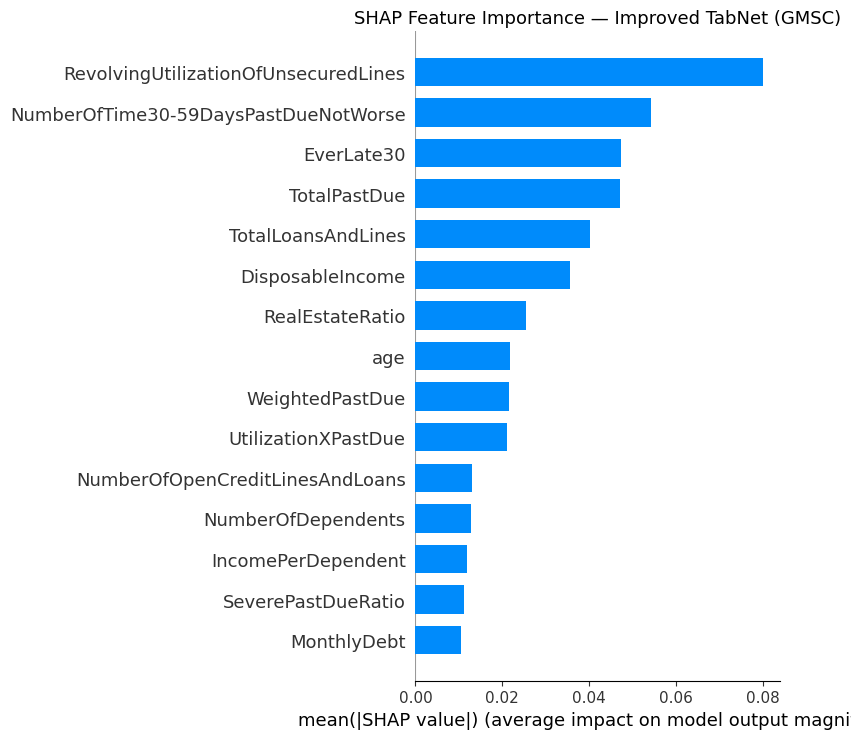

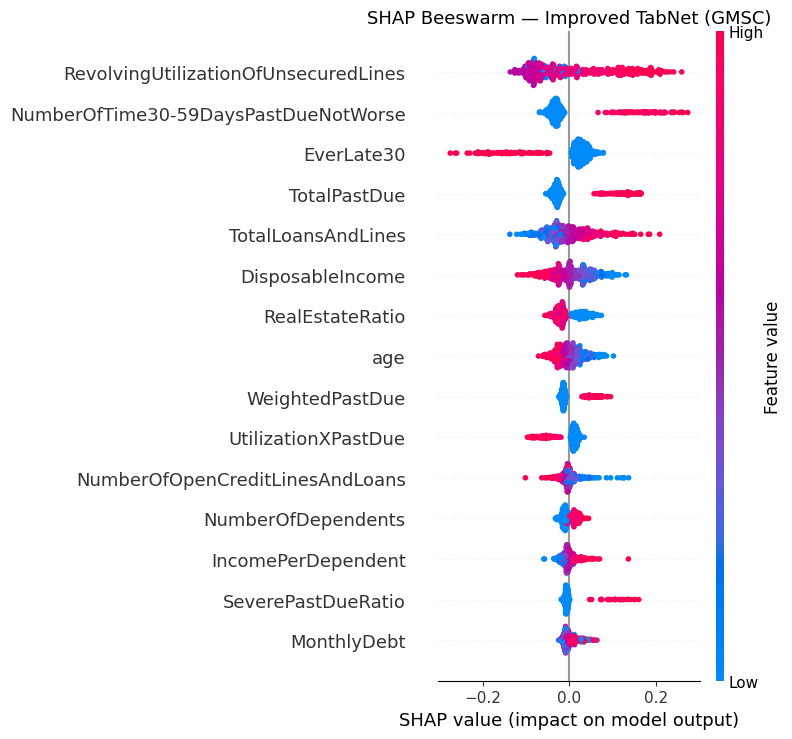

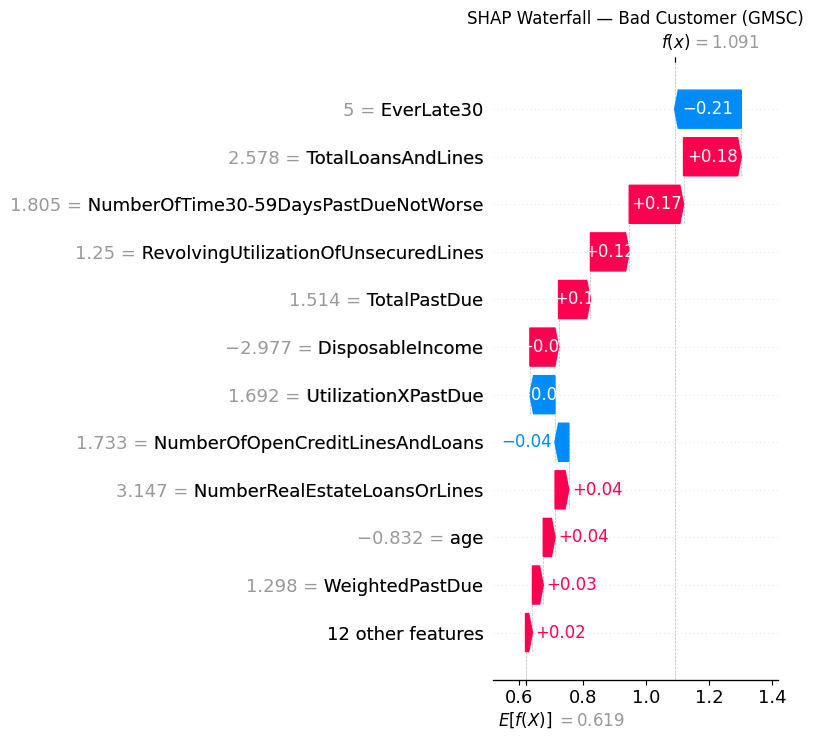

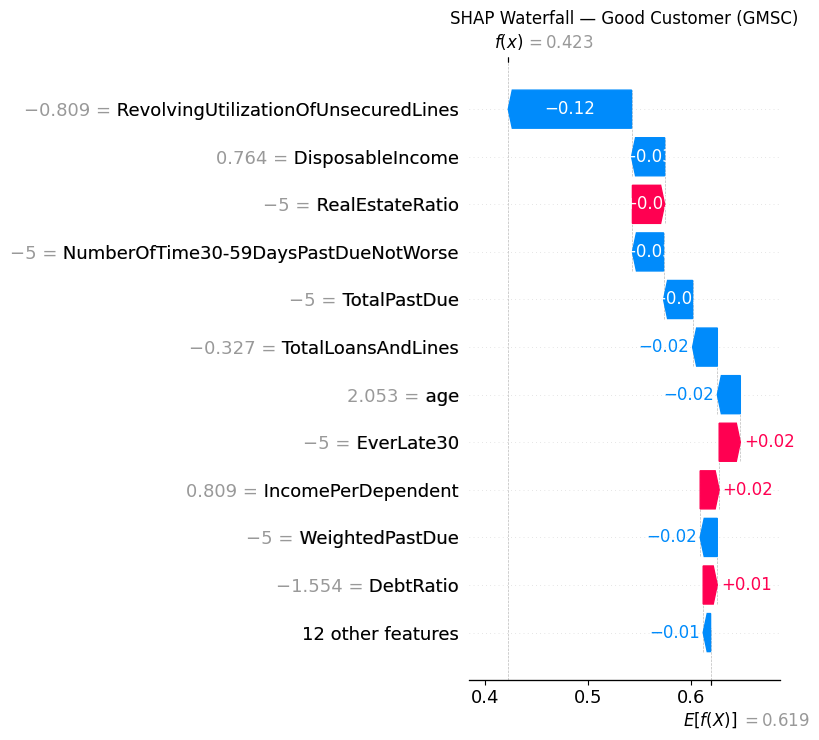


Top 10 SHAP features (GMSC):
RevolvingUtilizationOfUnsecuredLines    0.079941
NumberOfTime30-59DaysPastDueNotWorse    0.054293
EverLate30                              0.047295
TotalPastDue                            0.047080
TotalLoansAndLines                      0.040141
DisposableIncome                        0.035635
RealEstateRatio                         0.025464
age                                     0.021814
WeightedPastDue                         0.021595
UtilizationXPastDue                     0.021048


In [51]:
print('='*60)
print('SHAP Analysis — Give Me Some Credit')
print('='*60)

shap.initjs()

sv_gm, mean_shap_gm = run_shap_analysis(
    model_raw   = raw_model_gm_final,
    X_train_np  = X_gm_fe_tr_np,
    X_test_np   = X_gm_fe_te_np,
    y_test_np   = y_gm_test.values.astype(np.int64),
    feat_names  = list(X_gm_train_tn.columns),
    tag         = 'GMSC',
)

# PHẦN B - THỐNG KÊ & BÁO CÁO


── Risk Tiering (Give Me Some Credit) ──
            tier  Count  Bad_Rate  Avg_Prob  Bad_Rate_pct
 Medium (10–30%)   3420  0.002632  0.273607          0.26
   High (30–50%)  14226  0.013215  0.390792          1.32
Very High (>50%)  12354  0.146349  0.666266         14.63


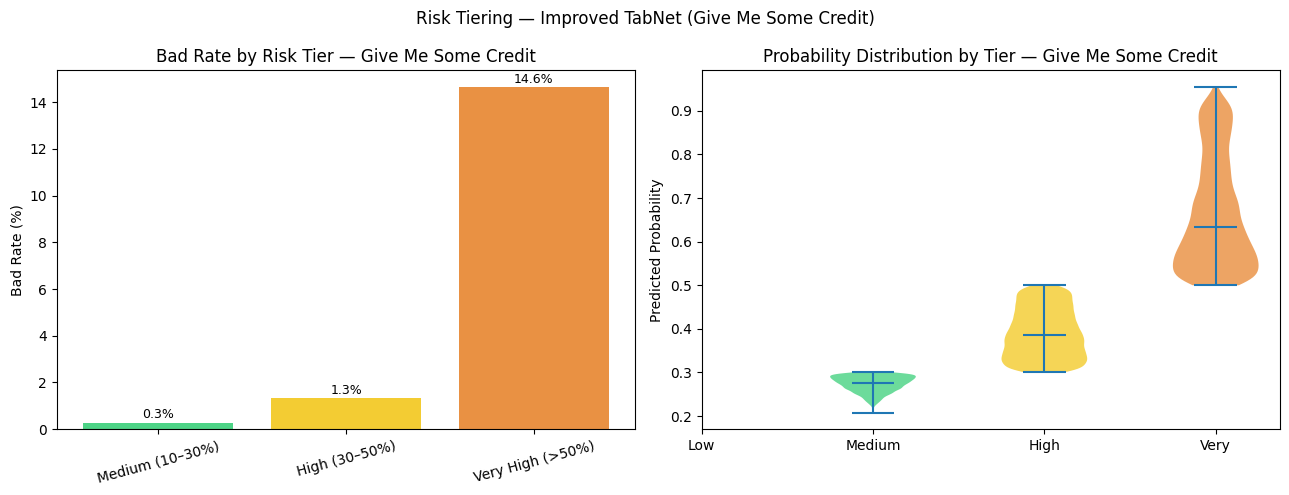

In [54]:
# GMSC
stats_gm = run_risk_tiering(
    wrapper_gm_final, X_gm_fe_te_np, y_gm_test.values.astype(np.int64),
    tag='Give Me Some Credit',
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low (<30%)', 'Medium (30–50%)', 'High (50–70%)', 'Very High (>70%)']
)



In [69]:
# ============================================================
# 1. TabNet default (pytorch-tabnet gốc)
# ============================================================
p_default = tabnet_gm_fe_default.predict_proba(X_gm_fe_te_np)[:, 1]
results_gm['TabNet'] = {
    'y_true': y_gm_test.values.astype(np.int64),
    'y_prob': p_default,
    'auc': roc_auc_score(y_gm_test, p_default),
}

# ============================================================
# 2. Improved TabNet (Optuna best, MHA+Focal) — model đề xuất cuối cùng
# ============================================================
p_final = wrapper_gm_final.predict_proba(X_gm_test_tn)[:, 1]
results_gm['Improved TabNet (Optuna best, MHA+Focal)'] = {
    'y_true': y_gm_test.values.astype(np.int64),
    'y_prob': p_final,
    'auc': te_m_gm_final['auc'],
}

print('✓ results_gm hiện có:')
for k in results_gm:
    print(' -', k)

✓ results_gm hiện có:
 - Logistic Regression
 - Decision Tree
 - Random Forest
 - XGBoost
 - LightGBM
 - CatBoost
 - Improved TabNet (Optuna best, MHA+Focal)
 - TabNet (default)
 - TabNet Optuna
 - TabNet


In [70]:
df_summary_gm

,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s),Dataset
0,"Improved TabNet (Optuna best, MHA+Focal)",0.8694,0.8704,0.7407,0.5857,0.2226,0.7810,0.8046,0.3464,1566,5470,22525,439,0.6098,157.02,Give Me Some Credit
1,TabNet + MHA + BCE Loss,0.8676,0.8700,0.7400,0.5821,0.1888,0.8409,0.7412,0.3084,1686,7244,20751,319,0.4278,NaN,Give Me Some Credit
2,TabNet + no MHA + Focal Loss,0.8694,0.8688,0.7377,0.5808,0.2137,0.7885,0.7922,0.3363,1581,5816,22179,424,0.5878,NaN,Give Me Some Credit
3,TabNet + MHA + Focal Loss,0.8673,0.8688,0.7376,0.5820,0.2023,0.8110,0.7710,0.3238,1626,6411,21584,379,0.5464,NaN,Give Me Some Credit
4,TabNet,0.8699,0.8680,0.7361,0.5802,0.2258,0.7691,0.8111,0.3491,1542,5288,22707,463,0.5460,248.54,Give Me Some Credit
5,LightGBM,0.9014,0.8660,0.7321,0.5786,0.2062,0.7990,0.7796,0.3277,1602,6169,21826,403,0.4552,0.85,Give Me Some Credit
6,Random Forest,0.8770,0.8658,0.7316,0.5824,0.2116,0.7945,0.7879,0.3341,1593,5937,22058,412,0.4500,14.31,Give Me Some Credit
7,Logistic Regression,0.8600,0.8654,0.7308,0.5734,0.2096,0.7855,0.7878,0.3309,1575,5940,22055,430,0.4889,1.4,Give Me Some Credit
8,CatBoost,0.9344,0.8570,0.7141,0.5612,0.2049,0.7771,0.7841,0.3243,1558,6044,21951,447,0.4110,17.85,Give Me Some Credit
9,Decision Tree,0.8632,0.8548,0.7096,0.5709,0.2037,0.7930,0.7779,0.3241,1590,6217,21778,415,0.5232,0.77,Give Me Some Credit


C. Thống kê & Báo cáo — Give Me Some Credit

── C1a. Summary — Give Me Some Credit ──
                                   Model  Train AUC  Test AUC  Test Gini  Test KS  F1 (Bad)
Improved TabNet (Optuna best, MHA+Focal)     0.8694    0.8704     0.7407   0.5857    0.3464
               TabNet + MHA + Focal Loss     0.8673    0.8688     0.7376   0.5820    0.3238
                                  TabNet     0.8699    0.8680     0.7361   0.5802    0.3491
                                LightGBM     0.9014    0.8660     0.7321   0.5786    0.3277
                           Random Forest     0.8770    0.8658     0.7316   0.5824    0.3341
                     Logistic Regression     0.8600    0.8654     0.7308   0.5734    0.3309
                                CatBoost     0.9344    0.8570     0.7141   0.5612    0.3243
                           Decision Tree     0.8632    0.8548     0.7096   0.5709    0.3241
                                 XGBoost     0.9442    0.8500     0.7000   0.5520    0

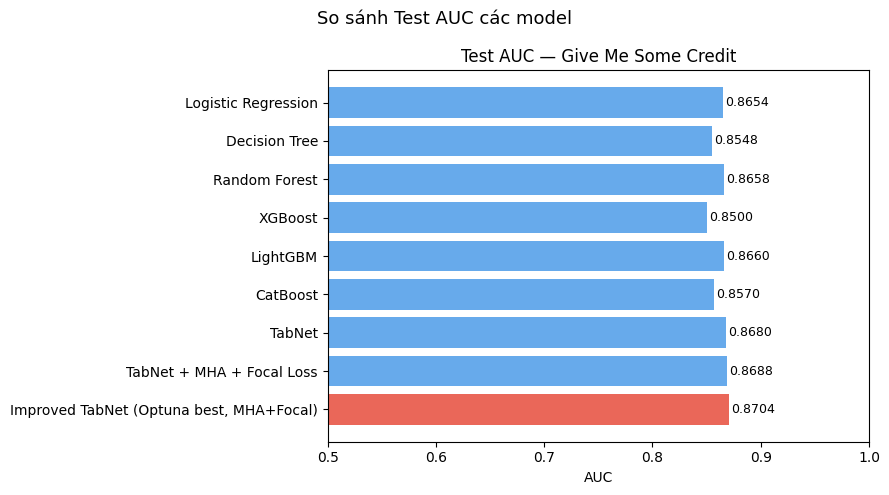


── C3. ROC Curve  ──


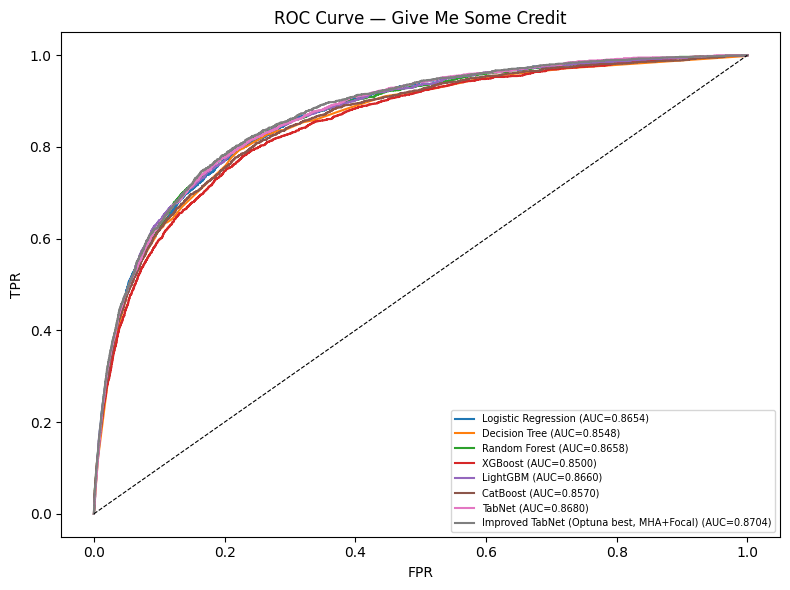


── C4. KS Chart  ──
Best model (trong nhóm chính): Improved TabNet (Optuna best, MHA+Focal)


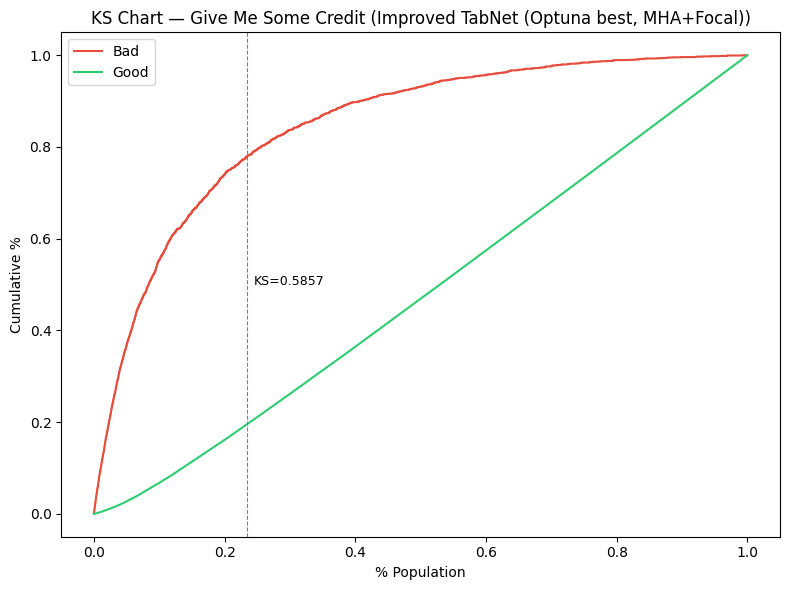


── C5. Confusion Matrix  ──

── Classification Report — Give Me Some Credit (Improved TabNet (Optuna best, MHA+Focal)) ──
              precision    recall  f1-score   support

        Good       0.99      0.62      0.76     27995
         Bad       0.15      0.90      0.25      2005

    accuracy                           0.64     30000
   macro avg       0.57      0.76      0.51     30000
weighted avg       0.93      0.64      0.73     30000



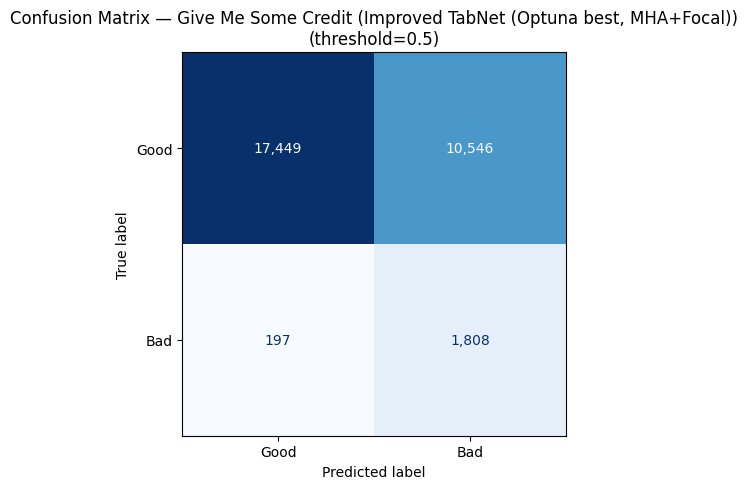

In [71]:
print('='*60)
print('C. Thống kê & Báo cáo — Give Me Some Credit')
print('='*60)

import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

# ============================================================
# Danh sách model chính (dùng xuyên suốt C1a, C2, C3, C4, C5)
# ============================================================
main_models_order = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost',
    'LightGBM',
    'CatBoost',
    'TabNet',
    'TabNet + MHA + Focal Loss',
    'Improved TabNet (Optuna best, MHA+Focal)'
]

# ============================================================
# C1a. Summary Table — các model chính
# ============================================================
print('\n── C1a. Summary — Give Me Some Credit ──')
df_c1a = df_summary_gm[df_summary_gm['Model'].isin(main_models_order)].copy()
df_c1a = df_c1a.sort_values('Test AUC', ascending=False).reset_index(drop=True)
print(df_c1a[['Model','Train AUC','Test AUC','Test Gini','Test KS','F1 (Bad)']].to_string(index=False))

# ============================================================
# C1b. Ablation Table — các biến thể TabNet
# ============================================================
ablation_models_order = [
    'TabNet + MHA + BCE Loss',
    'TabNet + no MHA + Focal Loss',
    'TabNet + MHA + Focal Loss',
    'TabNet',
]
print('\n── C1b. Ablation Study — TabNet (MHA / Focal Loss) ──')
df_c1b = df_summary_gm[df_summary_gm['Model'].isin(ablation_models_order)].copy()
df_c1b = df_c1b.sort_values('Test AUC', ascending=False).reset_index(drop=True)
print(df_c1b[['Model','Train AUC','Test AUC','Test Gini','Test KS','F1 (Bad)']].to_string(index=False))


# ============================================================
# C2. Bar chart so sánh Test AUC — chỉ model chính
# ============================================================
print('\n── C2. Bar chart  ──')
df_c2 = df_summary_gm[df_summary_gm['Model'].isin(main_models_order)].copy()
df_c2['Model'] = pd.Categorical(df_c2['Model'], categories=main_models_order, ordered=True)
df_c2 = df_c2.sort_values('Model')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E74C3C' if v == df_c2['Test AUC'].max() else '#4C9BE8' for v in df_c2['Test AUC']]
bars = ax.barh(df_c2['Model'], df_c2['Test AUC'], color=colors, alpha=0.85)
ax.invert_yaxis()
ax.set_xlim(0.5, 1.0)
ax.set_title('Test AUC — Give Me Some Credit')
ax.set_xlabel('AUC')
for bar, v in zip(bars, df_c2['Test AUC']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('So sánh Test AUC các model', fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# C3. ROC Curve — chỉ model chính
# ============================================================
print('\n── C3. ROC Curve  ──')
results_gm_main = {k: v for k, v in results_gm.items() if k in main_models_order}

def plot_roc_all(results, title, ax, order=None):
    keys = order if order else list(results.keys())
    for name in keys:
        if name not in results:
            continue
        res = results[name]
        fpr, tpr, _ = roc_curve(res['y_true'], res['y_prob'])
        ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.4f})", lw=1.5)
    ax.plot([0,1],[0,1], 'k--', lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Curve — {title}')
    ax.legend(fontsize=7, loc='lower right')

fig, ax = plt.subplots(figsize=(8, 6))
plot_roc_all(results_gm_main, 'Give Me Some Credit', ax, order=main_models_order)
plt.tight_layout()
plt.show()

# ============================================================
# C4. KS Chart — best model trong nhóm chính
# ============================================================
print('\n── C4. KS Chart  ──')
def plot_ks(y_true, y_prob, title, ax):
    df_ks = pd.DataFrame({'prob': y_prob, 'actual': y_true})
    df_ks = df_ks.sort_values('prob', ascending=False).reset_index(drop=True)
    df_ks['cum_bad']  = (df_ks['actual'] == 1).cumsum() / (df_ks['actual'] == 1).sum()
    df_ks['cum_good'] = (df_ks['actual'] == 0).cumsum() / (df_ks['actual'] == 0).sum()
    df_ks['ks'] = df_ks['cum_bad'] - df_ks['cum_good']
    pct = np.linspace(0, 1, len(df_ks))
    ax.plot(pct, df_ks['cum_bad'],  label='Bad',  color='#E74C3C')
    ax.plot(pct, df_ks['cum_good'], label='Good', color='#2ECC71')
    ks_max = df_ks['ks'].max()
    ks_idx = df_ks['ks'].idxmax()
    ax.axvline(pct[ks_idx], color='gray', linestyle='--', lw=0.8)
    ax.text(pct[ks_idx]+0.01, 0.5, f'KS={ks_max:.4f}', fontsize=9)
    ax.set_title(f'KS Chart — {title}')
    ax.set_xlabel('% Population'); ax.set_ylabel('Cumulative %')
    ax.legend()

best_gm = max(results_gm_main, key=lambda k: results_gm_main[k]['auc'])
print('Best model (trong nhóm chính):', best_gm)

fig, ax = plt.subplots(figsize=(8, 6))
plot_ks(results_gm_main[best_gm]['y_true'], results_gm_main[best_gm]['y_prob'],
        f'Give Me Some Credit ({best_gm})', ax)
plt.tight_layout()
plt.show()

# ============================================================
# C5. Confusion Matrix — best model trong nhóm chính
# ============================================================
print('\n── C5. Confusion Matrix  ──')
def plot_cm(y_true, y_prob, title, ax, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Good','Bad'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    for text in ax.texts:
        text.set_text(f'{int(text.get_text()):,}')
    ax.set_title(f'Confusion Matrix — {title}\n(threshold={threshold})')
    print(f'\n── Classification Report — {title} ──')
    print(classification_report(y_true, y_pred, target_names=['Good','Bad']))

fig, ax = plt.subplots(figsize=(6, 5))
plot_cm(results_gm_main[best_gm]['y_true'], results_gm_main[best_gm]['y_prob'],
        f'Give Me Some Credit ({best_gm})', ax)
plt.tight_layout()
plt.show()

# PHẦN C - SAVE


In [73]:
# ============================================================
# PHẦN C - SAVE: Đóng gói model + bảng + hình → demo package
# ============================================================
import os, json, pickle, shutil
import torch
import numpy as np

# ── 0. Thiết lập đường dẫn ───────────────────────────────────
save_dir = '/kaggle/working/demo_package_gmsc'
for sub in ['model', 'figures', 'tables']:
    os.makedirs(f'{save_dir}/{sub}', exist_ok=True)

# ── 1. Model: Improved TabNet (Optuna best, MHA+Focal) ──────
torch.save(raw_model_gm_final.state_dict(), f'{save_dir}/model/tabnet_model_weights.pt')

model_config = {
    'n_features': X_gm_train_tn.shape[1],
    'n_d': bp['n_d'], 'n_steps': bp['n_steps'], 'n_heads': bp['n_heads'],
    'd_model': bp['d_model'], 'dropout': bp['dropout'], 'gamma': bp['gamma'],
    'use_mha': True,
}
with open(f'{save_dir}/model/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

# ── 2. Feature names + threshold + metric ────────────────────
feature_names = list(X_gm_train_tn.columns)
with open(f'{save_dir}/model/feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)

threshold_info = {
    'optimal_threshold': float(te_m_gm_final.get('threshold', 0.5)),
    'test_auc':  float(te_m_gm_final['auc']),
    'test_gini': float(te_m_gm_final.get('gini', 0)),
    'test_ks':   float(te_m_gm_final.get('ks', 0)),
}
with open(f'{save_dir}/model/threshold_info.json', 'w') as f:
    json.dump(threshold_info, f, indent=2)

# ── 3. Pipeline tiền xử lý ────────────────────────────────────
preprocessing_objects = {'quantile_transformer': qt_gm}
with open(f'{save_dir}/model/preprocessing.pkl', 'wb') as f:
    pickle.dump(preprocessing_objects, f)

# ── 4. Sample data demo thử nhanh ────────────────────────────
n_samples_demo = 20
np.savez(f'{save_dir}/model/sample_data.npz',
         X=X_gm_fe_te_np[:n_samples_demo], y=y_gm_test.values[:n_samples_demo])

# ── 5. Export class kiến trúc — bản viết tay, khớp cell 18-19 ─
architecture_code = '''import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha, self.gamma, self.pos_weight = alpha, gamma, pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none')
        pt  = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


class MultiHeadAttention(nn.Module):
    def __init__(self, n_features, d_model=64, n_heads=8, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model, self.n_heads = d_model, n_heads
        self.d_k  = d_model // n_heads
        self.W_Q  = nn.Linear(1, d_model)
        self.W_K  = nn.Linear(1, d_model)
        self.W_V  = nn.Linear(1, d_model)
        self.W_O  = nn.Linear(d_model, 1)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(n_features)

    def forward(self, x):
        B, F_ = x.shape
        t     = x.unsqueeze(-1)
        Q, K, V = self.W_Q(t), self.W_K(t), self.W_V(t)
        def sh(z): return z.view(B, F_, self.n_heads, self.d_k).transpose(1, 2)
        Q, K, V = sh(Q), sh(K), sh(V)
        A   = self.drop(torch.softmax(Q @ K.transpose(-2,-1) / self.d_k**0.5, dim=-1))
        out = (A @ V).transpose(1,2).contiguous().view(B, F_, self.d_model)
        return self.norm(self.W_O(out).squeeze(-1) + x)


class ImprovedTabNetClassifier(nn.Module):
    def __init__(self, n_features, n_d=64, n_steps=5,
                 n_heads=8, d_model=64, dropout=0.1, gamma=1.5,
                 use_mha=True):
        super().__init__()
        self.n_features, self.n_steps, self.n_d, self.gamma = n_features, n_steps, n_d, gamma
        self.use_mha = use_mha

        if self.use_mha:
            self.mha_local  = MultiHeadAttention(n_features, d_model, n_heads,   dropout)
            self.mha_global = MultiHeadAttention(n_features, d_model*2, n_heads*2, dropout)
            shared_in_dim = n_features * 3
        else:
            self.mha_local  = None
            self.mha_global = None
            shared_in_dim = n_features

        self.shared_fc = nn.Sequential(
            nn.Linear(shared_in_dim, n_d*2), nn.BatchNorm1d(n_d*2), nn.GLU(dim=-1))

        self.step_fc = nn.ModuleList([
            nn.Sequential(nn.Linear(n_d, n_d*2), nn.BatchNorm1d(n_d*2), nn.GLU(dim=-1))
            for _ in range(n_steps)])

        self.attn_fc = nn.ModuleList([
            nn.Sequential(nn.Linear(n_d, n_features), nn.Softmax(dim=-1))
            for _ in range(n_steps)])

        self.proj_fc = nn.ModuleList([
            nn.Linear(n_features, n_d, bias=False)
            for _ in range(n_steps)])

        self.bn_in = nn.BatchNorm1d(n_features)
        self.drop  = nn.Dropout(dropout)
        self.head  = nn.Linear(n_d, 1)

    def _encode(self, x):
        x = self.bn_in(x)

        if self.use_mha:
            h_input = torch.cat([x, self.mha_local(x), self.mha_global(x)], dim=-1)
        else:
            h_input = x

        h = self.shared_fc(h_input)
        prior = torch.ones(x.size(0), self.n_features, device=x.device)
        agg   = torch.zeros(x.size(0), self.n_d,       device=x.device)
        ent   = torch.zeros(1,                          device=x.device)

        for i in range(self.n_steps):
            mask  = self.attn_fc[i](h) * prior
            mask  = mask / (mask.sum(-1, keepdim=True) + 1e-8)
            prior = prior * (self.gamma - mask)
            ent   = ent + (-mask * torch.log(mask + 1e-15)).sum(-1).mean()

            proj  = torch.relu(self.proj_fc[i](mask * x))
            step_out = torch.relu(self.step_fc[i](h) + proj * 0.5)
            agg  += step_out
            h = h + self.drop(step_out)

        return agg / self.n_steps, ent / self.n_steps

    def get_embedding(self, x):
        emb, _ = self._encode(x)
        return emb

    def forward(self, x):
        emb, ent = self._encode(x)
        return self.head(emb).squeeze(-1), ent
'''
with open(f'{save_dir}/model/model_architecture.py', 'w') as f:
    f.write(architecture_code)
print('✓ Đã ghi model_architecture.py')

# ── 6. Script load_model.py để demo ──────────────────────────
load_script = '''import torch, json, pickle
import numpy as np
from model_architecture import ImprovedTabNetClassifier

def load_demo_model(save_dir='.'):
    with open(f'{save_dir}/model_config.json') as f:
        config = json.load(f)
    model = ImprovedTabNetClassifier(
        n_features=config['n_features'], n_d=config['n_d'], n_steps=config['n_steps'],
        n_heads=config['n_heads'], d_model=config['d_model'],
        dropout=config['dropout'], gamma=config['gamma'], use_mha=config['use_mha'])
    model.load_state_dict(torch.load(f'{save_dir}/tabnet_model_weights.pt', map_location='cpu'))
    model.eval()
    with open(f'{save_dir}/feature_names.json') as f:
        feature_names = json.load(f)
    with open(f'{save_dir}/preprocessing.pkl', 'rb') as f:
        preprocessing = pickle.load(f)
    with open(f'{save_dir}/threshold_info.json') as f:
        threshold_info = json.load(f)
    return model, feature_names, preprocessing, threshold_info

def preprocess_raw_input(X_raw_df, preprocessing, feature_names):
    X_raw_df = X_raw_df[feature_names]
    qt = preprocessing['quantile_transformer']
    return qt.transform(X_raw_df).astype(np.float32)

def predict(model, X_processed_np):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(X_processed_np.astype(np.float32))
        logits, _ = model(x)
        return torch.sigmoid(logits).numpy()

if __name__ == '__main__':
    model, feat_names, preproc, thresh_info = load_demo_model()
    data = np.load('sample_data.npz')
    X_sample, y_sample = data['X'], data['y']
    probs = predict(model, X_sample)
    threshold = thresh_info['optimal_threshold']
    preds = (probs >= threshold).astype(int)
    for i in range(len(X_sample)):
        status = 'REJECT (Bad)' if preds[i] == 1 else 'APPROVE (Good)'
        print(f"Sample {i}: prob={probs[i]:.4f} -> {status} | true_label={y_sample[i]}")
'''
with open(f'{save_dir}/model/load_model.py', 'w') as f:
    f.write(load_script)

# ── 7. Bảng kết quả ───────────────────────────────────────────
df_summary_gm.to_csv(f'{save_dir}/tables/full_summary_gm.csv', index=False)
df_c1a.to_csv(f'{save_dir}/tables/C1a_summary_main_models.csv', index=False)
df_c1b.to_csv(f'{save_dir}/tables/C1b_ablation_tabnet.csv', index=False)

risk_csv = f'{OUTPUT_DIR}/risk_tiering_give_me_some_credit.csv'
if os.path.exists(risk_csv):
    shutil.copy(risk_csv, f'{save_dir}/tables/risk_tiering.csv')

# ── 8. Copy hình đã xuất từ OUTPUT_DIR ───────────────────────
figures_to_copy = [
    'C2_auc_comparison.png', 'C3_roc_curves.png',
    'C4_ks_chart.png', 'C5_confusion_matrix.png',
    'risk_tiering_give_me_some_credit.png',
    'shap_bar_gmsc.png', 'shap_beeswarm_gmsc.png',
]
for fname in figures_to_copy:
    src = f'{OUTPUT_DIR}/{fname}'
    if os.path.exists(src):
        shutil.copy(src, f'{save_dir}/figures/{fname}')
    else:
        print(f'⚠️ Không tìm thấy: {src}')

# ── 9. README ─────────────────────────────────────────────────
readme = f'''# Demo Package — Improved TabNet (Optuna best, MHA+Focal) — Give Me Some Credit

## Kết quả chính
- Test AUC  : {te_m_gm_final['auc']:.4f}
- Test Gini : {te_m_gm_final.get('gini', 'N/A')}
- Test KS   : {te_m_gm_final.get('ks', 'N/A')}

## Cách demo
```bash
cd model
pip install torch numpy
python load_model.py
```
'''
with open(f'{save_dir}/README.md', 'w') as f:
    f.write(readme)

# ── 10. Nén thành 1 file ZIP ─────────────────────────────────
zip_base = '/kaggle/working/demo_package_gmsc'
shutil.make_archive(zip_base, 'zip', save_dir)
zip_path = zip_base + '.zip'

print(f'\n✓ Đã đóng gói: {zip_path}')
print(f'✓ Kích thước: {os.path.getsize(zip_path)/1024:.1f} KB')
for root, dirs, files in os.walk(save_dir):
    level = root.replace(save_dir, '').count(os.sep)
    print('  '*level + os.path.basename(root) + '/')
    for f_ in files:
        print('  '*(level+1) + f_)

✓ Đã ghi model_architecture.py

✓ Đã đóng gói: /kaggle/working/demo_package_gmsc.zip
✓ Kích thước: 778.8 KB
demo_package_gmsc/
  README.md
  tables/
    risk_tiering.csv
    C1b_ablation_tabnet.csv
    full_summary_gm.csv
    C1a_summary_main_models.csv
  model/
    preprocessing.pkl
    model_config.json
    threshold_info.json
    feature_names.json
    model_architecture.py
    load_model.py
    tabnet_model_weights.pt
    sample_data.npz
  figures/
    C2_auc_comparison.png
    shap_beeswarm_gmsc.png
    C4_ks_chart.png
    risk_tiering_give_me_some_credit.png
    C3_roc_curves.png
    C5_confusion_matrix.png
    shap_bar_gmsc.png
